In [1]:
import os 
import json 
import numpy as np 

parent_dir = "/tudelft/abharadwaj1/staff-bulk/tnw/BN/AJ/AB/model_angelo_dataset"
locscale222_training_dir = "/home/abharadwaj1/papers/elife_paper/figure_information/data/locscale_MF_version_C"
training_info_json_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/calibration/cubedata_modelangelo_dataset_hyperparameters.json"

dir1 = "/tudelft/abharadwaj1/staff-umbrella/ajlab/AB/parking_for_files/fromDB/large_scale_feature_enhance"
dir2 = "/tudelft/abharadwaj1/staff-umbrella/ajlab/AB/parking_for_files/fromDB/locscale_dataset_version_feature_enhance_G_new"
#U:\ajlab\AB\parking_for_files\fromDB\large_scale_feature_enhance"
emdb_ids_in_calibration = [x.split("_")[1] for x in os.listdir(dir1) if x.startswith("emd_")]
emdb_ids_in_calibration2 = [x.split("_")[1] for x in os.listdir(dir2) if x.startswith("emd_")]
unique_emdb_ids = set(emdb_ids_in_calibration + emdb_ids_in_calibration2)
print(f"Unique EMDB IDs in calibration: {len(unique_emdb_ids)}")


with open(training_info_json_path, 'r') as f:
    training_info = json.load(f)


Unique EMDB IDs in calibration: 184


In [2]:
def check_unit_cell_emdb(emdb):
    import requests
    url = f"https://www.ebi.ac.uk/emdb/api/entry/map/{emdb}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        try:
            shape = data["map"]["dimensions"]["col"]
            apix = float(data["map"]["pixel_spacing"]["x"]["valueOf_"])
            #print(f"EMDB: {emdb}, Shape: {shape}, Pixel Size: {apix} Å")
            return shape, apix
        except KeyError:
            print(f"EMDB: {emdb} - Missing dimensions or pixel spacing information.")
            return None, None


In [ ]:
emdb_id_parent_dir = [x.split("_")[1] for x in os.listdir(parent_dir) if x.startswith("emd")]
print(f"Length of EMDB IDs in parent directory: {len(emdb_id_parent_dir)}")
emdb_id_locscale222_training_dir = [x.split("_")[0] for x in os.listdir(locscale222_training_dir) if os.path.isdir(os.path.join(locscale222_training_dir, x))]
print(f"Length of EMDB IDs in locscale222 training directory: {len(emdb_id_locscale222_training_dir)}")

In [ ]:
training_emdb_id = training_info["dataset_characteristics"]["training_id"]
validation_emdb_id = training_info["dataset_characteristics"]["validation_id"]
print(f"Length of training EMDB IDs: {len(training_emdb_id)}")
print(f"Length of validation EMDB IDs: {len(validation_emdb_id)}")



In [ ]:
emdb_id_in_parent_not_in_training = set(emdb_id_parent_dir) - set(training_emdb_id)
print(f"Length of EMDB IDs in parent directory but not in training set: {len(emdb_id_in_parent_not_in_training)}")
emdb_id_in_parent_not_in_locscale222_or_in_training = set(emdb_id_parent_dir) - set(locscale222_training_dir) - set(training_emdb_id)
print(f"Length of EMDB IDs in parent directory but not in locscale222 training directory or training set: {len(emdb_id_in_parent_not_in_locscale222_or_in_training)}")

In [ ]:
calibration_size = 50 
np.random.seed(42)  # For reproducibility
calibration_emdb_id = np.random.choice(list(emdb_id_in_parent_not_in_training), size=calibration_size, replace=False)
print(f"Calibration EMDB IDs: {calibration_emdb_id}")

In [ ]:
os.path.exists(feature_enhanced_map_source)

In [10]:
# copy halfmap files for calibration EMDB IDs to a new directory
output_directory = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/calibration_for_locscale222_broad_dataset"
os.makedirs(output_directory, exist_ok=True)
emdb_ids_with_files = {}

# check whether feature enhanced map is prsent for all calibration EMDB IDs from parent directory
feature_enhanced_map_file_format = "emd_{}_feature_enhance_locscale_2_2_mean.mrc"
baseline_map_file_format = "emd_{}_feature_enhance_locscale_2_2_locscale_output.mrc"
variance_map_file_format = "emd_{}_feature_enhance_locscale_2_2_var.mrc"

for emdb in unique_emdb_ids:
    # check whether it is present in dir1 or dir2 and set the source directory accordingly
    dir1_present = os.path.isdir(os.path.join(dir1, f"emd_{emdb}"))
    dir2_present = os.path.isdir(os.path.join(dir2, f"emd_{emdb}"))
    if not dir1_present and not dir2_present:
        continue
    if dir1_present:
        parent_dir_source = os.path.join(dir1, f"emd_{emdb}")
        feature_enhanced_map_file_format = "emd_{}_feature_enhance_locscale_2_2_mean.mrc"
        baseline_map_file_format = "emd_{}_feature_enhance_locscale_2_2_locscale_output.mrc"
        variance_map_file_format = "emd_{}_feature_enhance_locscale_2_2_var.mrc"
        mask_map_file_format = "emd_{}_feature_enhance_locscale_processing_2_2/EMD_{}_unsharpened_fullmap_confidenceMap.mrc"
    elif dir2_present:
        parent_dir_source = os.path.join(dir2, f"emd_{emdb}")
        feature_enhanced_map_file_format = "emd_emd_{}_feature_enhance_locscale_G_mean.mrc"
        baseline_map_file_format = "emd_emd_{}_feature_enhance_locscale_G_locscale_output.mrc"
        variance_map_file_format = "emd_emd_{}_feature_enhance_locscale_G_var.mrc"
        mask_map_file_format = "emd_emd_{}_feature_enhance_locscale_processing_G/EMD_{}_unsharpened_fullmap_confidenceMap.mrc"
        

    emdb_dir_destination = os.path.join(output_directory, f"emd_{emdb}")
    #os.makedirs(emdb_dir_destination, exist_ok=True)
    
    
    feature_enhanced_map_source = os.path.join(parent_dir_source, feature_enhanced_map_file_format.format(emdb))
    baseline_map_source = os.path.join(parent_dir_source, baseline_map_file_format.format(emdb))
    variance_map_source = os.path.join(parent_dir_source, variance_map_file_format.format(emdb))
    mask_source = os.path.join(parent_dir_source, mask_map_file_format.format(emdb, emdb))
    
    mask_present = os.path.isfile(mask_source)

    feature_enhanced_map_present = os.path.isfile(feature_enhanced_map_source)
    baseline_map_present = os.path.isfile(baseline_map_source)
    variance_map_present = os.path.isfile(variance_map_source)
    
    if mask_present and feature_enhanced_map_present and baseline_map_present and variance_map_present:
        emdb_ids_with_files[emdb] = {
            "mask": mask_source,
            "feature_enhanced_map": feature_enhanced_map_source,
            "baseline_map": baseline_map_source,
            "variance_map": variance_map_source
        }
    #else: 
        #print(f"Missing files for EMDB ID {emdb}:")
        #print(f"mask: {mask_present}, feature_enhanced_map: {feature_enhanced_map_present}, baseline_map: {baseline_map_present}, variance_map: {variance_map_present}")
print(f"Number of EMDB IDs with all required files: {len(emdb_ids_with_files)}")
    

Number of EMDB IDs with all required files: 115


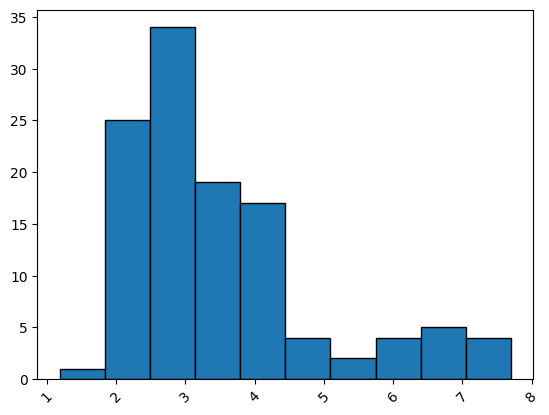

In [22]:
import requests
import matplotlib.pyplot as plt
def emdb_resolution(emdb_id):
    url = f"https://www.ebi.ac.uk/emdb/api/entry/processing/{emdb_id}"

    response = requests.get(url)
    if response.status_code == 200:
        resolution = response.json()["processing"]["final_reconstruction"]["final_reconstruction_type"]["resolution"]["valueOf_x"]
        return resolution
    else:
        raise ValueError(f"EMDB ID {emdb_id} not found or API error.")

resolutions = {}
for emdb_id in emdb_ids_with_files.keys():
    try:
        res = emdb_resolution(emdb_id)
        resolutions[emdb_id] = float(res)
    except ValueError as e:
        print(e)
plt.hist(list(resolutions.values()), bins=10, edgecolor='black');
plt.xticks(rotation=45);

In [ ]:
# import pandas as pd
# from tqdm import tqdm
# map_cell_data = []
# for emdb, files in tqdm(emdb_ids_with_files.items()):
#     shape, apix = check_unit_cell_emdb(emdb)
#     if shape is not None and apix is not None:
#         map_cell_data.append({
#             "emdb_id": emdb,
#             "shape": shape,
#             "apix": apix,
#             "cell" : shape * apix
#         })
# map_cell_df = pd.DataFrame(map_cell_data)
# # show distribution of cell 


In [ ]:
# import matplotlib.pyplot as plt
# map_cell_df["cell"].hist(bins=20)
# emdb_id_with_small_cell = map_cell_df[map_cell_df["cell"] < 300]["emdb_id"].tolist()

Number of EMDB IDs with resolution worse than 5 Å: 26
Selected calibration EMDB IDs: ['33493', '26563', '33506', '26923', '33062', '27395', '15948', '28962', '35402', '28649', '15589', '35274', '25834', '15205', '40510', '26071', '16036', '26331', '27750', '15631', '33558', '28536', '33571', '29291', '26867', '34653', '27251', '33481', '27984', '28666', '15037', '15175', '33876', '29365', '14718', '26178', '29494', '27668', '27662', '35691', '29327', '28153', '35984', '33501', '27329', '26355', '14144', '15803', '35121', '29709']
Length of calibration EMDB IDs: 50


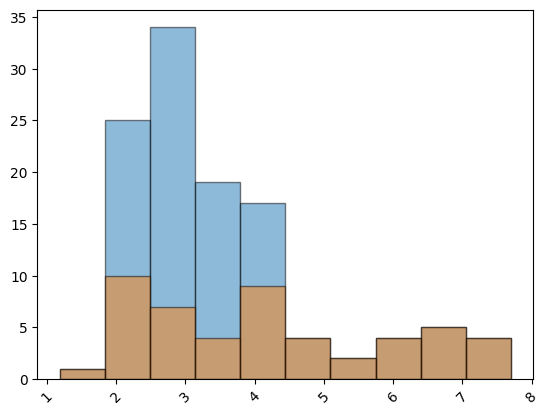

In [52]:
import random
#random.seed(42)  # For reproducibility
#np.random.seed(42)  # For reproducibility
emdb_ids_with_files_list = list(emdb_ids_with_files.keys())
calibration_length = 50
#calibration_emdb_ids = random.sample(emdb_ids_with_files_list, 50)
# sample calibration emdb ids to get uniform distribution of resolutions in the calibration set
resolutions_list = [float(resolutions[emdb_id]) for emdb_id in emdb_ids_with_files_list]
calibration_emdb_ids = []
resolution_bins = np.linspace(min(resolutions_list), max(resolutions_list), num=11)  
# include all maps with resolution worse than 5 Å in the calibration set and then sample the rest of the calibration EMDB IDs to get uniform distribution of resolutions in the calibration set
for emdb_id in emdb_ids_with_files_list:
    if resolutions[emdb_id] > 4:
        calibration_emdb_ids.append(emdb_id)

print(f"Number of EMDB IDs with resolution worse than 5 Å: {len(calibration_emdb_ids)}")
while len(calibration_emdb_ids) < calibration_length:
    sampled_emdb_id = random.choice(emdb_ids_with_files_list)
    if sampled_emdb_id in calibration_emdb_ids:
        continue
    sampled_resolution = resolutions[sampled_emdb_id]
    if sampled_resolution > 4:
        continue
    else:
        #bin_index = np.digitize(sampled_resolution, resolution_bins) - 1
        #if bin_index < len(resolution_bins) - 1:  
        #    calibration_emdb_ids.append(sampled_emdb_id)
        choose_probability = 0.1
        if random.random() < choose_probability:
            calibration_emdb_ids.append(sampled_emdb_id)



print(f"Selected calibration EMDB IDs: {calibration_emdb_ids}")
print(f"Length of calibration EMDB IDs: {len(calibration_emdb_ids)}")
# plot the distribution of resolutions in the calibration set and compare it to the distribution of resolutions in the full set
calibration_resolutions = [resolutions[emdb_id] for emdb_id in calibration_emdb_ids]
plt.hist(resolutions_list, bins=10, edgecolor='black', alpha=0.5, label='Full Set');
plt.hist(calibration_resolutions, bins=10, edgecolor='black', alpha=0.5, label='Calibration Set');
plt.xticks(rotation=45);

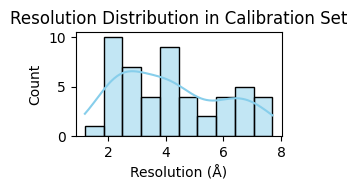

In [71]:
resolutions_in_calibration_list = [resolutions[emdb_id] for emdb_id in calibration_emdb_ids]
import seaborn as sns
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42
fig, ax = plt.subplots(figsize=(3, 2))
sns.histplot(resolutions_in_calibration_list, bins=10, kde=True, ax=ax, color='skyblue', edgecolor='black')
plt.xlabel("Resolution (Å)")
plt.ylabel("Count")
plt.title("Resolution Distribution in Calibration Set")
plt.tight_layout()
save_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/calibration/resolution_distribution_calibration_set.pdf"
plt.savefig(save_path, dpi=600)



In [55]:
import shutil

def copy_all_files(emdb_id, emdb_id_with_files):
    emdb_dir_destination = os.path.join(output_directory, f"emd_{emdb_id}")
    os.makedirs(emdb_dir_destination, exist_ok=True)
    for file_type, source_path in emdb_id_with_files[emdb_id].items():
        destination_filename = f"emd_{emdb_id}_{file_type}.mrc"
        destination_path = os.path.join(emdb_dir_destination, destination_filename)
        # Copy the file
        shutil.copy2(source_path, destination_path)
        #print(f"Copied {file_type} for EMDB ID {emdb_id} to {destination_path}")

In [56]:
from tqdm import tqdm
import joblib

n_jobs = 10 
with joblib.Parallel(n_jobs=n_jobs) as parallel:
    parallel(joblib.delayed(copy_all_files)(emdb_id, emdb_ids_with_files) for emdb_id in tqdm(calibration_emdb_ids))

100%|██████████| 50/50 [00:56<00:00,  1.14s/it]


In [ ]:
# check whether feature enhanced map is prsent for all calibration EMDB IDs from parent directory
feature_enhanced_map_file_format = "emd_{}_feature_enhance_locscale_2_2_2_feature_enhanced_output.mrc"
baseline_map_file_format = "emd_{}_feature_enhance_locscale_2_2_2_locscale_output.mrc"
variance_map_file_format = "emd_{}_feature_enhance_locscale_2_2_2_variance.mrc"
fe_maps_baseline_present_emdb_ids = []
for emdb_id in calibration_emdb_ids:
    feature_enhanced_map_path = os.path.join(parent_dir, f"emd_{emdb_id}", feature_enhanced_map_file_format.format(emdb_id))
    baseline_map_path = os.path.join(parent_dir, f"emd_{emdb_id}", baseline_map_file_format.format(emdb_id))
    variance_map_path = os.path.join(parent_dir, f"emd_{emdb_id}", variance_map_file_format.format(emdb_id))
    if os.path.isfile(feature_enhanced_map_path) and os.path.isfile(baseline_map_path) and os.path.isfile(variance_map_path):
        fe_maps_baseline_present_emdb_ids.append(emdb_id)
    else:
        print(f"Missing files for EMDB ID {emdb_id}:")
        if not os.path.isfile(feature_enhanced_map_path):
            print(f"  Missing: {feature_enhanced_map_path}")
        if not os.path.isfile(baseline_map_path):
            print(f"  Missing: {baseline_map_path}")

print(f"Number of calibration EMDB IDs with both feature enhanced and baseline maps: {len(fe_maps_baseline_present_emdb_ids)}")

In [ ]:
# copy feature enhanced and baseline maps for calibration EMDB IDs to output directory
def copy_fe_and_baseline_maps(emdb_id):
    feature_enhanced_map_source = os.path.join(parent_dir, f"emd_{emdb_id}", feature_enhanced_map_file_format.format(emdb_id))
    baseline_map_source = os.path.join(parent_dir, f"emd_{emdb_id}", baseline_map_file_format.format(emdb_id))
    feature_enhanced_map_destination = os.path.join(output_directory, f"emd_{emdb_id}", os.path.basename(feature_enhanced_map_source))
    baseline_map_destination = os.path.join(output_directory, f"emd_{emdb_id}", os.path.basename(baseline_map_source))
    variance_map_source = os.path.join(parent_dir, f"emd_{emdb_id}", variance_map_file_format.format(emdb_id))
    variance_map_destination = os.path.join(output_directory, f"emd_{emdb_id}", os.path.basename(variance_map_source))

    if not os.path.exists(feature_enhanced_map_destination):
        shutil.copy2(feature_enhanced_map_source, feature_enhanced_map_destination)
    
    if not os.path.exists(baseline_map_destination):
        shutil.copy2(baseline_map_source, baseline_map_destination)
    
    if not os.path.exists(variance_map_destination):
        shutil.copy2(variance_map_source, variance_map_destination)
    
    #print(f"Copied feature enhanced and baseline maps for EMDB ID {emdb_id} to output directory.")

with joblib.Parallel(n_jobs=n_jobs) as parallel:
    parallel(joblib.delayed(copy_fe_and_baseline_maps)(emdb_id) for emdb_id in tqdm(fe_maps_baseline_present_emdb_ids))


In [58]:
emdb_ids_not_in_calibration_but_with_files = set(emdb_ids_with_files.keys()) - set(calibration_emdb_ids)
print(f"Number of EMDB IDs not in calibration set but with files: {len(emdb_ids_not_in_calibration_but_with_files)}")

Number of EMDB IDs not in calibration set but with files: 65


In [63]:
n_sample_test = 26 # to check calibration between feature enhanced and baseline maps for the calibration EMDB IDs, we will sample 15 EMDB IDs from the calibration set and compare the feature enhanced and baseline maps for those EMDB IDs
calibration_test_sample = random.sample(calibration_emdb_ids, n_sample_test)
# copy halfmap files for calibration EMDB IDs to a new directory
output_directory = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/test_calibration_15"
os.makedirs(output_directory, exist_ok=True)
emdb_ids_with_files_test = {}

# check whether feature enhanced map is prsent for all calibration EMDB IDs from parent directory
feature_enhanced_map_file_format = "emd_{}_feature_enhance_locscale_2_2_mean.mrc"
baseline_map_file_format = "emd_{}_feature_enhance_locscale_2_2_locscale_output.mrc"
variance_map_file_format = "emd_{}_feature_enhance_locscale_2_2_var.mrc"

for emdb in calibration_test_sample:
    # check whether it is present in dir1 or dir2 and set the source directory accordingly
    dir1_present = os.path.isdir(os.path.join(dir1, f"emd_{emdb}"))
    dir2_present = os.path.isdir(os.path.join(dir2, f"emd_{emdb}"))
    if not dir1_present and not dir2_present:
        continue
    if dir1_present:
        parent_dir_source = os.path.join(dir1, f"emd_{emdb}")
        feature_enhanced_map_file_format = "emd_{}_feature_enhance_locscale_2_2_mean.mrc"
        baseline_map_file_format = "emd_{}_feature_enhance_locscale_2_2_locscale_output.mrc"
        variance_map_file_format = "emd_{}_feature_enhance_locscale_2_2_var.mrc"
        mask_map_file_format = "emd_{}_feature_enhance_locscale_processing_2_2/EMD_{}_unsharpened_fullmap_confidenceMap.mrc"
    elif dir2_present:
        parent_dir_source = os.path.join(dir2, f"emd_{emdb}")
        feature_enhanced_map_file_format = "emd_emd_{}_feature_enhance_locscale_G_mean.mrc"
        baseline_map_file_format = "emd_emd_{}_feature_enhance_locscale_G_locscale_output.mrc"
        variance_map_file_format = "emd_emd_{}_feature_enhance_locscale_G_var.mrc"
        mask_map_file_format = "emd_emd_{}_feature_enhance_locscale_processing_G/EMD_{}_unsharpened_fullmap_confidenceMap.mrc"
        

    emdb_dir_destination = os.path.join(output_directory, f"emd_{emdb}")
    #os.makedirs(emdb_dir_destination, exist_ok=True)
    
    
    feature_enhanced_map_source = os.path.join(parent_dir_source, feature_enhanced_map_file_format.format(emdb))
    baseline_map_source = os.path.join(parent_dir_source, baseline_map_file_format.format(emdb))
    variance_map_source = os.path.join(parent_dir_source, variance_map_file_format.format(emdb))
    mask_source = os.path.join(parent_dir_source, mask_map_file_format.format(emdb, emdb))
    pvddt_source = os.path.join(parent_dir_source, "hallucinations_probabilities_map.mrc")

    mask_present = os.path.isfile(mask_source)
    feature_enhanced_map_present = os.path.isfile(feature_enhanced_map_source)
    baseline_map_present = os.path.isfile(baseline_map_source)
    variance_map_present = os.path.isfile(variance_map_source)
    pvddt_present = os.path.isfile(pvddt_source)
    
    if mask_present and feature_enhanced_map_present and baseline_map_present and variance_map_present and pvddt_present:
        emdb_ids_with_files_test[emdb] = {
            "mask": mask_source,
            "feature_enhanced_map": feature_enhanced_map_source,
            "baseline_map": baseline_map_source,
            "variance_map": variance_map_source,
            "pvddt": pvddt_source
        }
    else: 
        print(f"Missing files for EMDB ID {emdb}:")
        print(f"mask: {mask_present}, feature_enhanced_map: {feature_enhanced_map_present}, baseline_map: {baseline_map_present}, variance_map: {variance_map_present}")
print(f"Number of EMDB IDs with all required files: {len(emdb_ids_with_files_test)}")
    

Missing files for EMDB ID 27329:
mask: True, feature_enhanced_map: True, baseline_map: True, variance_map: True
Missing files for EMDB ID 35984:
mask: True, feature_enhanced_map: True, baseline_map: True, variance_map: True
Missing files for EMDB ID 27662:
mask: True, feature_enhanced_map: True, baseline_map: True, variance_map: True
Missing files for EMDB ID 26178:
mask: True, feature_enhanced_map: True, baseline_map: True, variance_map: True
Missing files for EMDB ID 14144:
mask: True, feature_enhanced_map: True, baseline_map: True, variance_map: True
Missing files for EMDB ID 29365:
mask: True, feature_enhanced_map: True, baseline_map: True, variance_map: True
Missing files for EMDB ID 29709:
mask: True, feature_enhanced_map: True, baseline_map: True, variance_map: True
Missing files for EMDB ID 33876:
mask: True, feature_enhanced_map: True, baseline_map: True, variance_map: True
Missing files for EMDB ID 14718:
mask: True, feature_enhanced_map: True, baseline_map: True, variance_ma

In [69]:
# copy files for the test calibration EMDB IDs to the new directory
from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
output_directory = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/testing_calibration"
os.makedirs(output_directory, exist_ok=True)
def copy_test_calibration_files(emdb_id, emdb_id_with_files):
    emdb_dir_destination = os.path.join(output_directory, f"emd_{emdb_id}")
    os.makedirs(emdb_dir_destination, exist_ok=True)
    for file_type, source_path in emdb_id_with_files[emdb_id].items():
    
        destination_filename = f"emd_{emdb_id}_{file_type}.mrc"
        destination_path = os.path.join(emdb_dir_destination, destination_filename)
        # Copy the file
        if os.path.exists(destination_path):
            print(f"File already exists: {destination_path}")
            return
        else:
            shutil.copy2(source_path, destination_path)
        #print(f"Copied {file_type} for EMDB ID {emdb_id} to {destination_path}")


In [70]:
with joblib.Parallel(n_jobs=n_jobs) as parallel:
    parallel(joblib.delayed(copy_test_calibration_files)(emdb_id, emdb_ids_with_files_test) for emdb_id in tqdm(emdb_ids_with_files_test.keys()))

100%|██████████| 15/15 [00:00<00:00, 20393.70it/s]

File already exists: /home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/testing_calibration/emd_34653/emd_34653_mask.mrc
File already exists: /home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/testing_calibration/emd_35402/emd_35402_mask.mrc
File already exists: /home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/testing_calibration/emd_27395/emd_27395_mask.mrc
File already exists: /home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/testing_calibration/emd_15631/emd_15631_mask.mrc
File already exists: /home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/testing_calibration/emd_26867/emd_26867_mask.mrc
File already exists: /home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/testing_cal